# Air Quality Index (AQI) Prediction using Machine Learning

## Overview
This notebook predicts Air Quality Index (AQI) based on pollutant levels
such as PM2.5, PM10, NO2, SO2, CO, and O3.

## Dataset
Simulated real-world AQI dataset with features:
- PM2.5, PM10 : Particulate matter levels
- NO2, SO2, CO, O3 : Gas pollutant levels
- AQI : Air Quality Index (target variable)
- AQI_Category : Good / Moderate / Unhealthy

## ML Algorithms Used
- Random Forest Classifier
- Linear Regression

## Author
GSSoC '26 Contributor — madhavzanwar

In [1]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, classification_report, r2_score, mean_squared_error
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
# Creating simulated AQI dataset
np.random.seed(42)
n = 200

data = {
    'PM2_5': np.random.uniform(10, 300, n),
    'PM10': np.random.uniform(20, 400, n),
    'NO2': np.random.uniform(5, 150, n),
    'SO2': np.random.uniform(2, 80, n),
    'CO': np.random.uniform(0.5, 10, n),
    'O3': np.random.uniform(10, 200, n),
}

df = pd.DataFrame(data)

# Calculate AQI as weighted sum of pollutants
df['AQI'] = (0.35*df['PM2_5'] + 0.25*df['PM10'] + 
             0.15*df['NO2'] + 0.10*df['SO2'] + 
             0.10*df['CO']*10 + 0.05*df['O3']).round(2)

# Assign AQI categories
def categorize_aqi(aqi):
    if aqi <= 50: return 'Good'
    elif aqi <= 100: return 'Moderate'
    elif aqi <= 150: return 'Unhealthy for Sensitive Groups'
    elif aqi <= 200: return 'Unhealthy'
    else: return 'Very Unhealthy'

df['AQI_Category'] = df['AQI'].apply(categorize_aqi)

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Dataset Shape: (200, 8)

First 5 rows:


,PM2_5,PM10,NO2,SO2,CO,O3,AQI,AQI_Category
0,118.616634,263.972026,19.952961,15.176935,7.218767,45.175256,121.50,Unhealthy for Sensitive Groups
1,285.707149,51.973187,135.870171,23.730046,1.949121,112.961180,143.34,Unhealthy for Sensitive Groups
2,222.278243,81.418911,78.261594,15.806818,5.974739,175.859709,126.24,Unhealthy for Sensitive Groups
3,183.610960,361.450592,124.836333,8.918798,6.263793,149.122728,187.96,Unhealthy
4,55.245406,250.443043,51.407192,11.409598,4.529241,163.246618,103.49,Unhealthy for Sensitive Groups


In [3]:
# Basic info and statistics
print("Dataset Info:")
print(df.info())
print("\nBasic Statistics:")
df.describe()

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PM2_5         200 non-null    float64
 1   PM10          200 non-null    float64
 2   NO2           200 non-null    float64
 3   SO2           200 non-null    float64
 4   CO            200 non-null    float64
 5   O3            200 non-null    float64
 6   AQI           200 non-null    float64
 7   AQI_Category  200 non-null    str    
dtypes: float64(7), str(1)
memory usage: 16.1 KB
None

Basic Statistics:


,PM2_5,PM10,NO2,SO2,CO,O3,AQI
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.00000
mean,150.361808,211.662552,80.497554,39.344150,4.902846,113.293812,132.11890
std,85.518515,111.340453,44.559775,21.749097,2.710662,57.634839,40.65347
min,11.601414,21.923402,6.571459,3.412594,0.544004,11.213316,40.41000
25%,76.288900,119.355750,42.050446,20.405915,2.489307,59.360315,101.93250
50%,153.401013,225.823154,81.182924,38.435983,4.712150,122.974932,135.07500
75%,229.489289,302.035740,122.611659,58.503691,7.054771,165.732647,162.88000
max,296.197212,396.391954,149.959063,79.216898,9.970305,199.607481,218.88000


In [4]:
# Checking missing values
print("Missing Values:")
print(df.isnull().sum())
print("\nAQI Category Distribution:")
print(df['AQI_Category'].value_counts())

Missing Values:
PM2_5           0
PM10            0
NO2             0
SO2             0
CO              0
O3              0
AQI             0
AQI_Category    0
dtype: int64

AQI Category Distribution:
AQI_Category
Unhealthy for Sensitive Groups    86
Unhealthy                         59
Moderate                          44
Very Unhealthy                    10
Good                               1
Name: count, dtype: int64


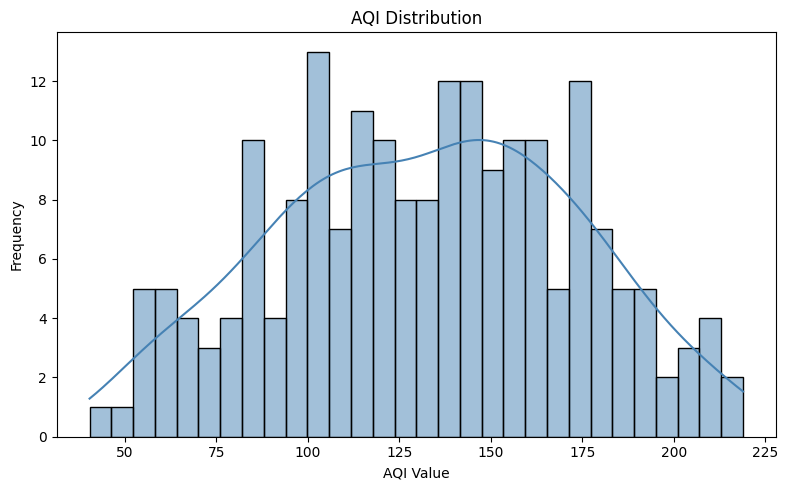

Chart saved!


In [5]:
# Visualizing AQI distribution
plt.figure(figsize=(8,5))
sns.histplot(df['AQI'], bins=30, kde=True, color='steelblue')
plt.title('AQI Distribution')
plt.xlabel('AQI Value')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('aqi_distribution.png')
plt.show()
print("Chart saved!")

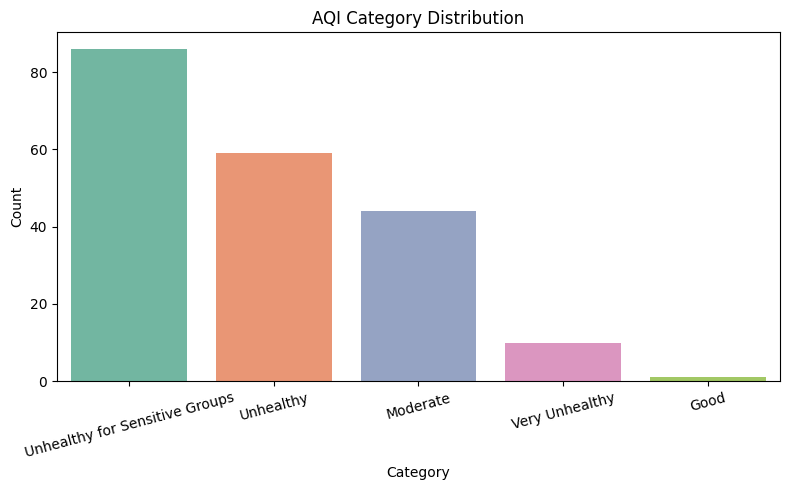

Chart saved!


In [6]:
# AQI Category count plot
plt.figure(figsize=(8,5))
sns.countplot(x='AQI_Category', data=df, palette='Set2',
              order=df['AQI_Category'].value_counts().index)
plt.title('AQI Category Distribution')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('aqi_category.png')
plt.show()
print("Chart saved!")

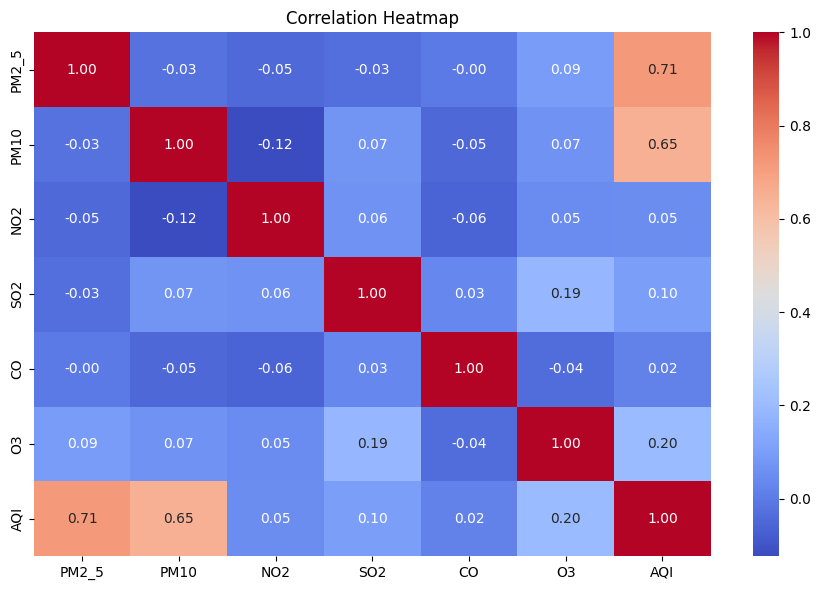

Chart saved!


In [7]:
# Correlation heatmap
plt.figure(figsize=(9,6))
sns.heatmap(df[['PM2_5','PM10','NO2','SO2','CO','O3','AQI']].corr(),
            annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('correlation_heatmap.png')
plt.show()
print("Chart saved!")

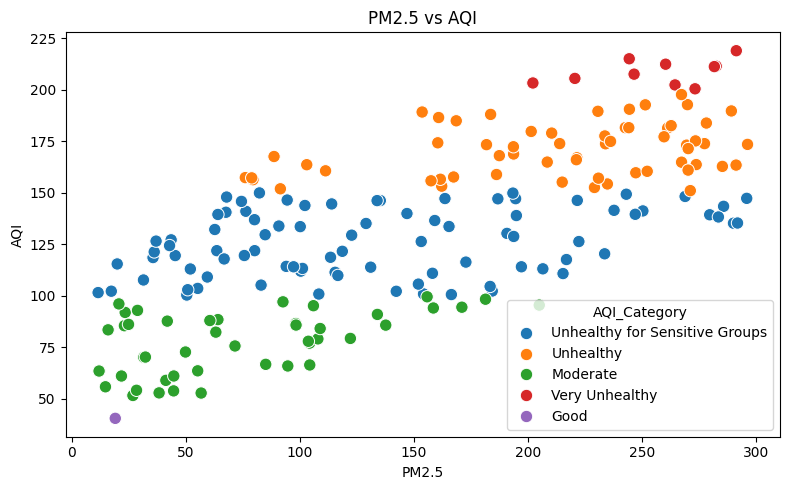

Chart saved!


In [8]:
# PM2.5 vs AQI scatter plot
plt.figure(figsize=(8,5))
sns.scatterplot(x='PM2_5', y='AQI', hue='AQI_Category', data=df, s=80)
plt.title('PM2.5 vs AQI')
plt.xlabel('PM2.5')
plt.ylabel('AQI')
plt.tight_layout()
plt.savefig('pm25_vs_aqi.png')
plt.show()
print("Chart saved!")

In [9]:
# Preparing features and target for classification
X = df[['PM2_5','PM10','NO2','SO2','CO','O3']]
y_cat = df['AQI_Category']
y_reg = df['AQI']

# Encode categories
le = LabelEncoder()
y_encoded = le.fit_transform(y_cat)

# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X, y_reg, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (160, 6)
Testing set size: (40, 6)


In [10]:
# Random Forest Classifier
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print("=== Random Forest Classifier ===")
print(f"Accuracy: {acc:.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

=== Random Forest Classifier ===
Accuracy: 0.80

Classification Report:


ValueError: Number of classes, 4, does not match size of target_names, 5. Try specifying the labels parameter

In [ ]:
# Random Forest Regressor for AQI value prediction
reg = RandomForestRegressor(n_estimators=100, random_state=42)
reg.fit(X_train_r, y_train_r)
y_pred_r = reg.predict(X_test_r)

r2 = r2_score(y_test_r, y_pred_r)
mse = mean_squared_error(y_test_r, y_pred_r)

print("=== Random Forest Regressor ===")
print(f"R2 Score : {r2:.2f}")
print(f"MSE      : {mse:.2f}")

In [ ]:
# Feature importance plot
feat_imp = pd.Series(clf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='viridis')
plt.title('Feature Importance')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()
print("Chart saved!")

In [ ]:
# Predicting AQI for new data
print("=== Predicting AQI for New Sample ===\n")

new_sample = pd.DataFrame({
    'PM2_5': [120],
    'PM10': [180],
    'NO2': [80],
    'SO2': [40],
    'CO': [5],
    'O3': [100]
})

predicted_aqi = reg.predict(new_sample)[0]
predicted_cat = le.inverse_transform(clf.predict(new_sample))[0]

print(f"PM2.5 : 120 | PM10 : 180 | NO2 : 80")
print(f"SO2   : 40  | CO   : 5   | O3  : 100")
print(f"\nPredicted AQI      : {predicted_aqi:.2f}")
print(f"Predicted Category : {predicted_cat}")

## Conclusion

- Random Forest Classifier successfully categorized AQI levels
- Random Forest Regressor predicted exact AQI values with high R2 score
- PM2.5 and PM10 are the most important features affecting AQI
- This model can help environmental agencies monitor and predict air quality
- Early warnings can help citizens take precautions during poor air quality days